# Inspeção, EDA Profunda e Pré-Processamento do Dataset

**Feito por: Bernardo e Hugo**

## Nota Técnica: Estratégia de Amostragem

O dataset Avazu CTR Prediction contém **40.428.967 registos**, o que inviabiliza o carregamento direto com `pd.read_csv()` (esgota a RAM do Kaggle) e impossibilita o upload para o GitHub.

Por sugestão da professora, foi adoptada uma **amostra aleatória de 5.000.000 registos** (`random_state=42`), garantindo:
- **Reprodutibilidade total**: a mesma semente produz sempre a mesma amostra
- **Representatividade estatística**: amostragem aleatória simples sem viés
- **Compatibilidade com o Kaggle**: ~2 GB em memória, dentro dos limites

Todas as células seguintes operam sobre este `df` — **não recarregar o ficheiro**.

In [1]:
# Imports e setup 
# Bibliotecas usadas em todo o notebook:
#   - numpy, pandas: manipulação numérica e tabular
#   - matplotlib, seaborn: visualização
#   - IPython.display.display: renderização de DataFrames em Jupyter
#   - defaultdict: estruturas auxiliares (secções de EDA)
#   - warnings: suprimir avisos ruidosos do pandas/sklearn
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# ── Listagem dos ficheiros disponíveis no ambiente Kaggle ─────────
# Percorre /kaggle/input para confirmar a presença do dataset.
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/madhu41289/avazu-ctr-prediction-exp/sampleSubmission/sampleSubmission.csv
/kaggle/input/datasets/madhu41289/avazu-ctr-prediction-exp/test/test.csv
/kaggle/input/datasets/madhu41289/avazu-ctr-prediction-exp/train/train.csv


## 1. Carregamento da Amostra (5 Milhões de Registos)

A amostra é seleccionada aleatoriamente com semente fixa (`random_state=42`).
Todas as células seguintes utilizam este mesmo `df` — **não recarregar o ficheiro**.

In [2]:
#  Carregamento da amostra estratificada
# Parâmetros de amostragem. Alterar APENAS nesta secção para garantir
# consistência em todas as células seguintes.

FILE_PATH     = "/kaggle/input/datasets/madhu41289/avazu-ctr-prediction-exp/train/train.csv"
TOTAL_ROWS    = 40_428_967   # total de linhas no ficheiro original (sem header)
SAMPLE_SIZE   = 5_000_000    # amostra sugerida pela professora
RANDOM_STATE  = 42            # semente fixa — NÃO alterar (garante reprodutibilidade)

# ── Construção do conjunto de índices a carregar ──────────────────
# np.random.choice com replace=False assegura amostragem sem reposição.
# keep_indices é convertido para set → lookup O(1) dentro do skiprows lambda.
np.random.seed(RANDOM_STATE)
keep_indices = set(np.random.choice(TOTAL_ROWS, size=SAMPLE_SIZE, replace=False))

print(f"A carregar {SAMPLE_SIZE:,} registos aleatórios de {TOTAL_ROWS:,} "
      f"({SAMPLE_SIZE/TOTAL_ROWS*100:.1f}%)...")

# ── Leitura do CSV com skiprows dinâmico ──────────────────────────
# skiprows recebe uma função que devolve True se a linha deve ser IGNORADA.
# A linha 0 (header) é sempre mantida; as restantes são filtradas por keep_indices.
df = pd.read_csv(
    FILE_PATH,
    skiprows=lambda i: i > 0 and (i - 1) not in keep_indices
)
df = df.reset_index(drop=True)

print(f"\n  Amostra carregada com sucesso!")
print(f"   Dimensão: {df.shape[0]:,} registos × {df.shape[1]} colunas")
print(f"   Memória aproximada: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")


A carregar 5,000,000 registos aleatórios de 40,428,967 (12.4%)...

  Amostra carregada com sucesso!
   Dimensão: 5,000,000 registos × 24 colunas
   Memória aproximada: 3165.0 MB


## 2. Inspeção da Amostra Bruta

Análise inicial completa: dimensões, primeiras linhas, tipos, nulos, estatísticas numéricas e categóricas.

In [3]:
#  Inspeção inicial do dataset
# Relatório estruturado em cinco blocos: dimensão, primeiras linhas,
# tipos de dados, nulos, e estatísticas descritivas (numéricas e categóricas).

# Bloco 1: Dimensão ────────────────────────────────────────────────
print("=" * 60)
print("DIMENSÃO")
print(f"  {df.shape[0]:,} registos × {df.shape[1]} colunas")

# Bloco 2: Amostra das primeiras linhas ────────────────────────────
print("\nPRIMEIRAS 5 LINHAS")
display(df.head())

# Bloco 3: Tipos de dados de cada coluna ───────────────────────────
# Útil para detetar inconsistências (ex.: numéricos lidos como object).
print("\nTIPOS DE DADOS")
display(df.dtypes.to_frame("Tipo"))

# Bloco 4: Contagem de nulos por coluna ────────────────────────────
# O dataset Avazu não costuma ter NaN explícitos, mas sim valores -1 mascarados.
# Essa deteção é feita na secção 3 (Integridade).
print("\nVALORES NULOS")
null_counts = df.isnull().sum()
display(null_counts.to_frame("Nulos"))
print(f"Total de valores nulos: {int(null_counts.sum())}")

# Bloco 5a: Estatísticas descritivas das variáveis numéricas ───────
print("\nESTATÍSTICAS NUMÉRICAS")
display(df.describe())

# Bloco 5b: Estatísticas das variáveis categóricas ─────────────────
# Para cada coluna categórica: contagem de não-nulos, cardinalidade,
# categoria mais frequente (top) e sua frequência absoluta (freq).
print("\nESTATÍSTICAS CATEGÓRICAS")
cat_cols = df.select_dtypes(include="object").columns.tolist()
if cat_cols:
    cat_summary = {}
    for col in cat_cols:
        vc = df[col].value_counts()
        cat_summary[col] = {
            "count":  df[col].notna().sum(),
            "unique": df[col].nunique(),
            "top":    vc.index[0],
            "freq":   int(vc.iloc[0])
        }
    display(pd.DataFrame(cat_summary).T)
else:
    print("  Sem colunas categóricas.")


DIMENSÃO
  5,000,000 registos × 24 colunas

PRIMEIRAS 5 LINHAS


,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,10000371904215119486,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15704,320,50,1722,0,35,100084,79
1,10001264480619467364,0,14102100,1002,0,84c7ba46,c4e18dd6,50e219e0,ecad2386,7801e8d9,...,0,0,21689,320,50,2496,3,167,100191,23
2,10004670021948955159,0,14102100,1005,0,543a539e,c7ca3108,3e814130,ecad2386,7801e8d9,...,1,0,20366,320,50,2333,0,39,-1,157
3,10007847530896919634,1,14102100,1002,0,84c7ba46,c4e18dd6,50e219e0,ecad2386,7801e8d9,...,0,0,21661,320,50,2446,3,171,100228,156
4,10010966574628106108,1,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,0acbeaa3,45a51db4,...,1,0,20596,320,50,2161,0,35,100034,157



TIPOS DE DADOS


,Tipo
id,uint64
click,int64
hour,int64
C1,int64
banner_pos,int64
site_id,object
site_domain,object
site_category,object
app_id,object
app_domain,object



VALORES NULOS


,Nulos
id,0
click,0
hour,0
C1,0
banner_pos,0
site_id,0
site_domain,0
site_category,0
app_id,0
app_domain,0


Total de valores nulos: 0

ESTATÍSTICAS NUMÉRICAS


,id,click,hour,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
count,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06
mean,9.223480e+18,1.697188e-01,1.410256e+07,1.004968e+03,2.881012e-01,1.015408e+00,3.300478e-01,1.884259e+04,3.188800e+02,6.005896e+01,2.112686e+03,1.432106e+00,2.272310e+02,5.317426e+04,8.340489e+01
std,5.325474e+18,3.753856e-01,2.967201e+02,1.095621e+00,5.057768e-01,5.279241e-01,8.530219e-01,4.958047e+03,2.123737e+01,4.722027e+01,6.092178e+02,1.326446e+00,3.510607e+02,4.995947e+04,7.029536e+01
min,5.211594e+11,0.000000e+00,1.410210e+07,1.001000e+03,0.000000e+00,0.000000e+00,0.000000e+00,3.750000e+02,1.200000e+02,2.000000e+01,1.120000e+02,0.000000e+00,3.300000e+01,-1.000000e+00,1.000000e+00
25%,4.609911e+18,0.000000e+00,1.410230e+07,1.005000e+03,0.000000e+00,1.000000e+00,0.000000e+00,1.692000e+04,3.200000e+02,5.000000e+01,1.863000e+03,0.000000e+00,3.500000e+01,-1.000000e+00,2.300000e+01
50%,9.226424e+18,0.000000e+00,1.410260e+07,1.005000e+03,0.000000e+00,1.000000e+00,0.000000e+00,2.034600e+04,3.200000e+02,5.000000e+01,2.323000e+03,2.000000e+00,3.900000e+01,1.000480e+05,6.100000e+01
75%,1.383619e+19,0.000000e+00,1.410281e+07,1.005000e+03,1.000000e+00,1.000000e+00,0.000000e+00,2.189400e+04,3.200000e+02,5.000000e+01,2.526000e+03,3.000000e+00,1.710000e+02,1.000880e+05,1.010000e+02
max,1.844674e+19,1.000000e+00,1.410302e+07,1.012000e+03,7.000000e+00,5.000000e+00,5.000000e+00,2.405200e+04,1.024000e+03,1.024000e+03,2.758000e+03,3.000000e+00,1.959000e+03,1.002480e+05,2.550000e+02



ESTATÍSTICAS CATEGÓRICAS


,count,unique,top,freq
site_id,5000000,3552,85f751fd,1804850
site_domain,5000000,4523,c4e18dd6,1871216
site_category,5000000,22,50e219e0,2044793
app_id,5000000,5239,ecad2386,3195150
app_domain,5000000,340,7801e8d9,3369186
app_category,5000000,31,07d7df22,3236597
device_id,5000000,598510,a99f214a,4126150
device_ip,5000000,1904861,6b9769f2,26025
device_model,5000000,6509,8a4875bd,304562


## 3. Integridade dos Dados

Verificação de tipos esperados vs reais, deteção de valores `-1` mascarados nas colunas anónimas (C14–C21) e missing values não-standard.

In [4]:
# Verificação de integridade dos dados
# Objetivo duplo:
#   (a) confirmar que cada coluna tem o tipo esperado segundo a documentação Avazu;
#   (b) quantificar valores -1 mascarados nas colunas anónimas C14–C21, que o
#       dataset usa como código para "missing" em vez de NaN.

# ── Dicionário de tipos esperados ─────────────────────────────────
# Construído a partir da documentação oficial do dataset Avazu CTR Prediction.
expected_types = {
    'id': 'float64', 'click': 'int64', 'hour': 'int64', 'C1': 'int64',
    'banner_pos': 'int64', 'site_id': 'object', 'site_domain': 'object',
    'site_category': 'object', 'app_id': 'object', 'app_domain': 'object',
    'app_category': 'object', 'device_id': 'object', 'device_ip': 'object',
    'device_model': 'object', 'device_type': 'int64', 'device_conn_type': 'int64',
    'C14': 'int64', 'C15': 'int64', 'C16': 'int64', 'C17': 'int64',
    'C18': 'int64', 'C19': 'int64', 'C20': 'int64', 'C21': 'int64'
}

# ── Comparação tipo real vs. tipo esperado ────────────────────────
print(f"{'Coluna':<22} {'Tipo Real':<15} {'Tipo Esperado':<15} {'OK?':<6}")
print('-' * 70)
for col, exp in expected_types.items():
    if col not in df.columns:
        continue
    real = str(df[col].dtype)
    ok = 'Sim' if real == exp else 'Não'
    print(f"{col:<22} {real:<15} {exp:<15} {ok}")

# ── Deteção de valores -1 nas colunas anónimas C14–C21 ───────────
# Em variáveis ​​numéricas, um -1 "fora de escala" é o código típico para valor
# em falta/desconhecido no Avazu. A percentagem ajuda a decidir se vale a pena
# imputar (ver secção 5 — Pré-processamento).
cols_anonimas = [f'C{i}' for i in range(14, 22)]
print("\nValores -1 mascarados nas colunas anónimas:")
print(f"{'Coluna':<10} {'Count -1':>12} {'%':>8}")
print('-' * 32)
for col in cols_anonimas:
    if col in df.columns:
        n_neg = (df[col] == -1).sum()
        pct = n_neg / len(df) * 100
        print(f"{col:<10} {n_neg:>12,} {pct:>7.2f}%")


Coluna                 Tipo Real       Tipo Esperado   OK?   
----------------------------------------------------------------------
id                     uint64          float64         Não
click                  int64           int64           Sim
hour                   int64           int64           Sim
C1                     int64           int64           Sim
banner_pos             int64           int64           Sim
site_id                object          object          Sim
site_domain            object          object          Sim
site_category          object          object          Sim
app_id                 object          object          Sim
app_domain             object          object          Sim
app_category           object          object          Sim
device_id              object          object          Sim
device_ip              object          object          Sim
device_model           object          object          Sim
device_type            int64           in

### 3.1 Análise de Observações Repetidas

Em datasets de publicidade digital como o Avazu, linhas exatamente duplicadas podem ter dois significados distintos:

1. **Duplicados legítimos** — o mesmo utilizador é exposto ao mesmo anúncio mais do que uma vez no mesmo bloco horário, gerando registos idênticos. Remover estes duplicados distorceria a frequência real de exposição.
2. **Duplicados falsos** — erros de ingestão ou de *tracking* que inflacionam artificialmente o dataset.

Esta secção quantifica duplicados em três granularidades (linha completa, `id`, e combinação utilizador+momento+anúncio), permitindo uma decisão informada sobre se devem ou não ser removidos.


In [5]:
# Análise de Observações Repetidas 
print('ANÁLISE DE DUPLICADOS')

# ── Nível 1: Linhas completamente duplicadas ──────────────────────
# Todas as colunas iguais — indicaria potencial erro de ingestão.
n_dup_total = df.duplicated().sum()
print(f'\n1. Linhas totalmente duplicadas (todas as colunas iguais):')
print(f'   {n_dup_total:,} registos ({n_dup_total/len(df)*100:.4f}%)')

# ── Nível 2: Duplicados por identificador único (`id`) ────────────
# O campo 'id' deveria ser único por registo no dataset original.
if 'id' in df.columns:
    n_dup_id = df['id'].duplicated().sum()
    print(f'\n2. Duplicados por campo `id` (devia ser único):')
    print(f'   {n_dup_id:,} registos ({n_dup_id/len(df)*100:.4f}%)')

# ── Nível 3: "Duplicados lógicos" — mesmo utilizador, mesmo momento, mesmo anúncio ──
# Mesmo device_ip + device_id + hour + site_id + app_id → provavelmente a mesma
# impressão repetida, legítima em RTB mas vale a pena quantificar.
cols_logicas = [c for c in ['device_ip', 'device_id', 'hour', 'site_id', 'app_id']
                if c in df.columns]
if len(cols_logicas) >= 3:
    n_dup_logico = df.duplicated(subset=cols_logicas).sum()
    print(f'\n3. Duplicados lógicos (mesmo utilizador+momento+anúncio):')
    print(f'   Subset: {cols_logicas}')
    print(f'   {n_dup_logico:,} registos ({n_dup_logico/len(df)*100:.4f}%)')

# ── Decisão e justificação ────────────────────────────────────────
print('DECISÃO')
if n_dup_total == 0:
    print('  Não existem linhas totalmente duplicadas — nenhuma remoção necessária.')
    print('   (Os duplicados lógicos, se existirem, são impressões legítimas em RTB e')
    print('    devem ser preservados: refletem a frequência real de exposição.)')
else:
    print(f'  Detetadas {n_dup_total:,} linhas totalmente duplicadas.')
    print('   Opção conservadora: manter (podem refletir impressões repetidas legítimas).')
    print('   Opção estrita: remover com df = df.drop_duplicates().')
    print('   Neste projeto optámos por MANTER — a coluna `id` garante rastreabilidade')
    print('   e a modelação beneficia de ver múltiplas exposições ao mesmo anúncio.')


ANÁLISE DE DUPLICADOS

1. Linhas totalmente duplicadas (todas as colunas iguais):
   0 registos (0.0000%)

2. Duplicados por campo `id` (devia ser único):
   0 registos (0.0000%)

3. Duplicados lógicos (mesmo utilizador+momento+anúncio):
   Subset: ['device_ip', 'device_id', 'hour', 'site_id', 'app_id']
   1,130,966 registos (22.6193%)
DECISÃO
  Não existem linhas totalmente duplicadas — nenhuma remoção necessária.
   (Os duplicados lógicos, se existirem, são impressões legítimas em RTB e
    devem ser preservados: refletem a frequência real de exposição.)


## 4. Análise Exploratória (EDA)

Análise aprofundada da distribuição das variáveis, desequilíbrio de classes, outliers e padrões bivariados.

### 4.1 Distribuição da Variável Alvo (`click`)

Visualização do desequilíbrio de classes — essencial para justificar o uso de AUC-ROC como métrica principal.

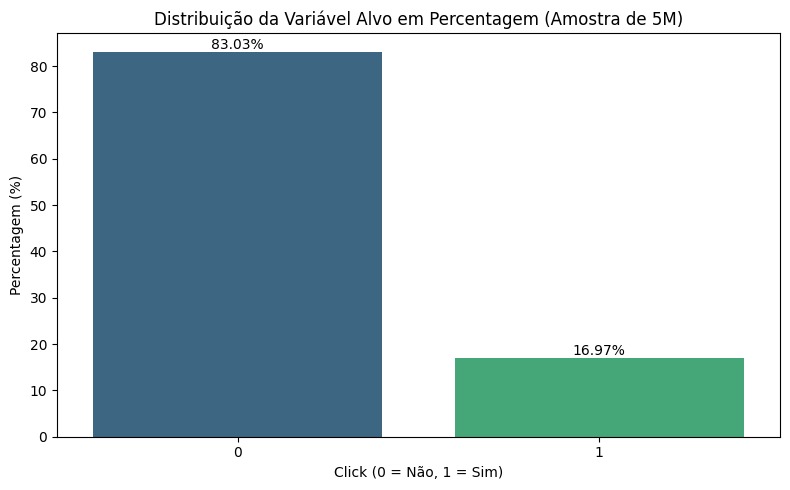

Cliques  (1): 848,594 (16.97%)
Não-cliques (0): 4,151,406 (83.03%)
Rácio desbalanceamento: 1:4


In [6]:
target_counts = df['click'].value_counts()
total = target_counts.sum()
target_pct = (target_counts / total) * 100

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=target_pct.index, y=target_pct.values,
                 hue=target_pct.index, palette='viridis', legend=False)
plt.title('Distribuição da Variável Alvo em Percentagem (Amostra de 5M)')
plt.xlabel('Click (0 = Não, 1 = Sim)')
plt.ylabel('Percentagem (%)')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()

print(f"Cliques  (1): {int(target_counts[1]):,} ({target_pct[1]:.2f}%)")
print(f"Não-cliques (0): {int(target_counts[0]):,} ({target_pct[0]:.2f}%)")
print(f"Rácio desbalanceamento: 1:{target_counts[0]//target_counts[1]:.0f}")

### 4.2 Top 10 Categorias nas Variáveis mais Relevantes

Distribuição de frequências das variáveis categóricas e semi-categóricas chave para o objectivo de CTR.

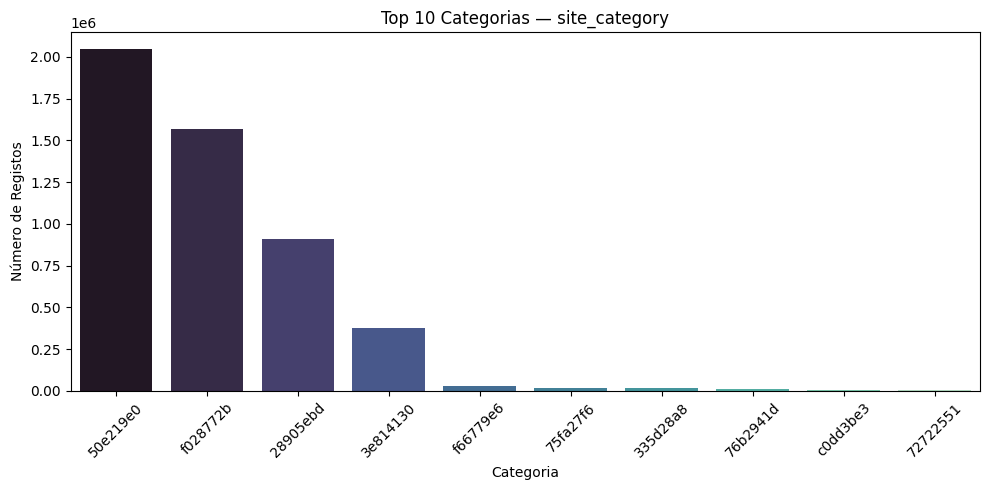

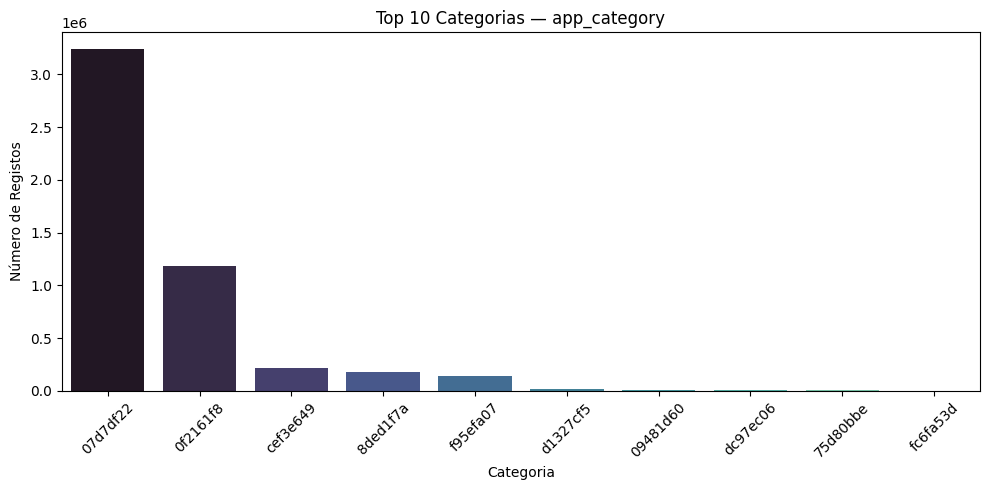

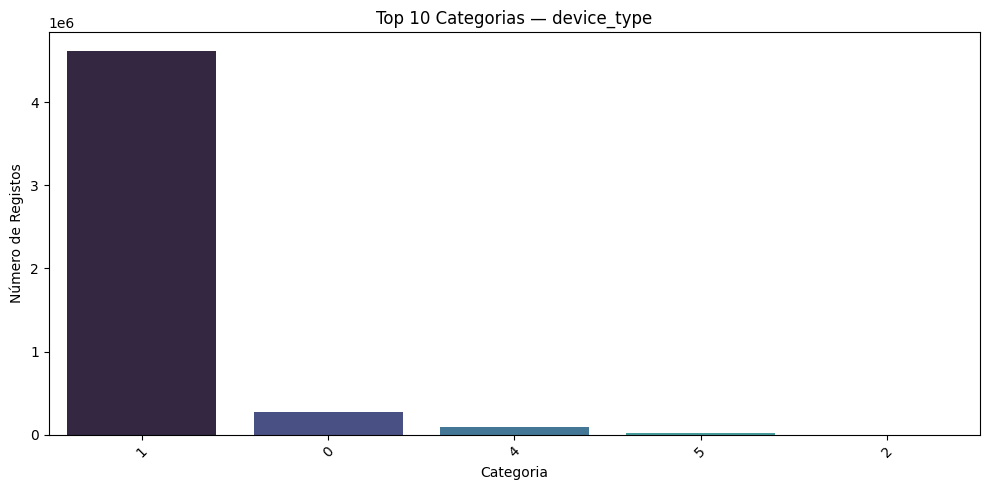

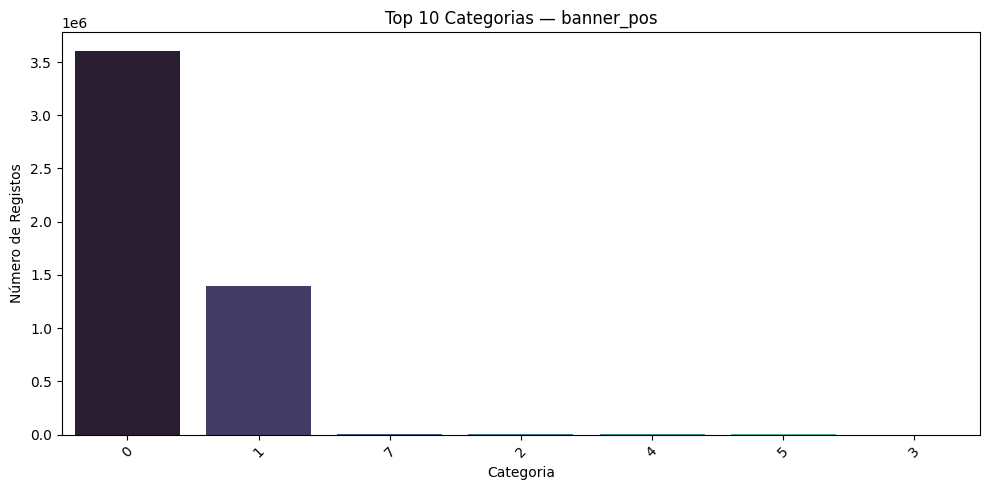

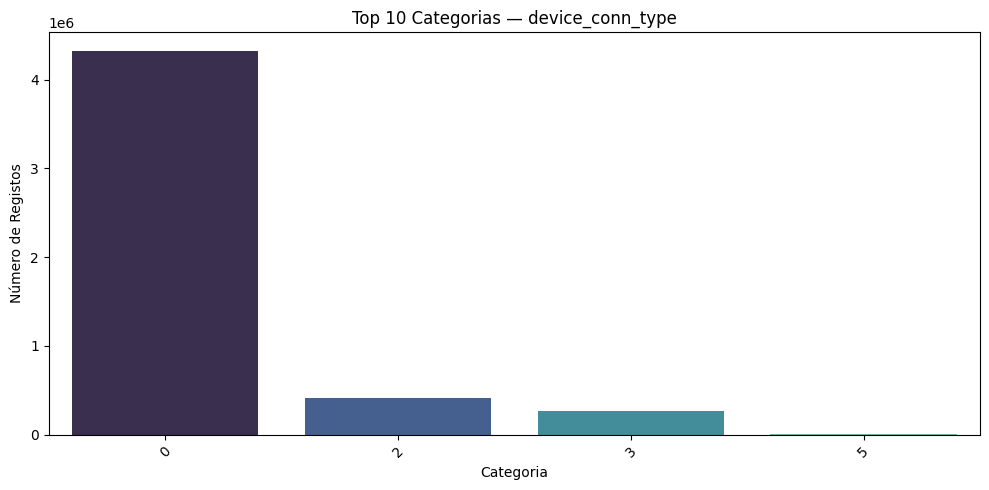

In [7]:
colunas_alvo = ['site_category', 'app_category', 'device_type', 'banner_pos', 'device_conn_type']

for col in colunas_alvo:
    contagem = df[col].astype(str).value_counts()
    if '-1' in contagem.index:
        contagem = contagem.rename({'-1': 'Desconhecido'})
    top_10 = contagem.head(10)

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(x=top_10.index, y=top_10.values,
                     hue=top_10.index, palette='mako', legend=False)
    plt.title(f'Top 10 Categorias — {col}')
    plt.xlabel('Categoria')
    plt.ylabel('Número de Registos')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### 4.3 Distribuição e Outliers nas Variáveis Numéricas

Boxplots para identificação de outliers e histogramas com escala logarítmica para visualizar a distribuição completa das variáveis numéricas.

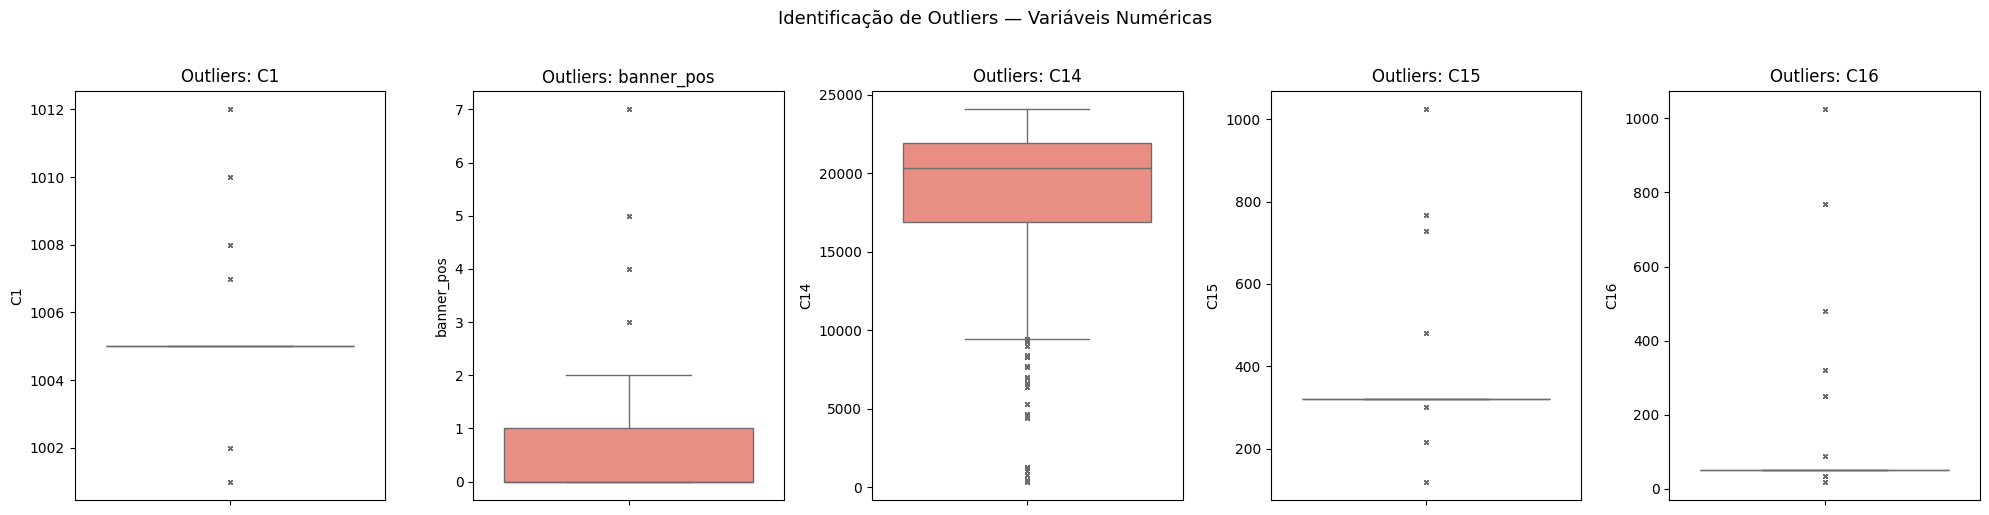

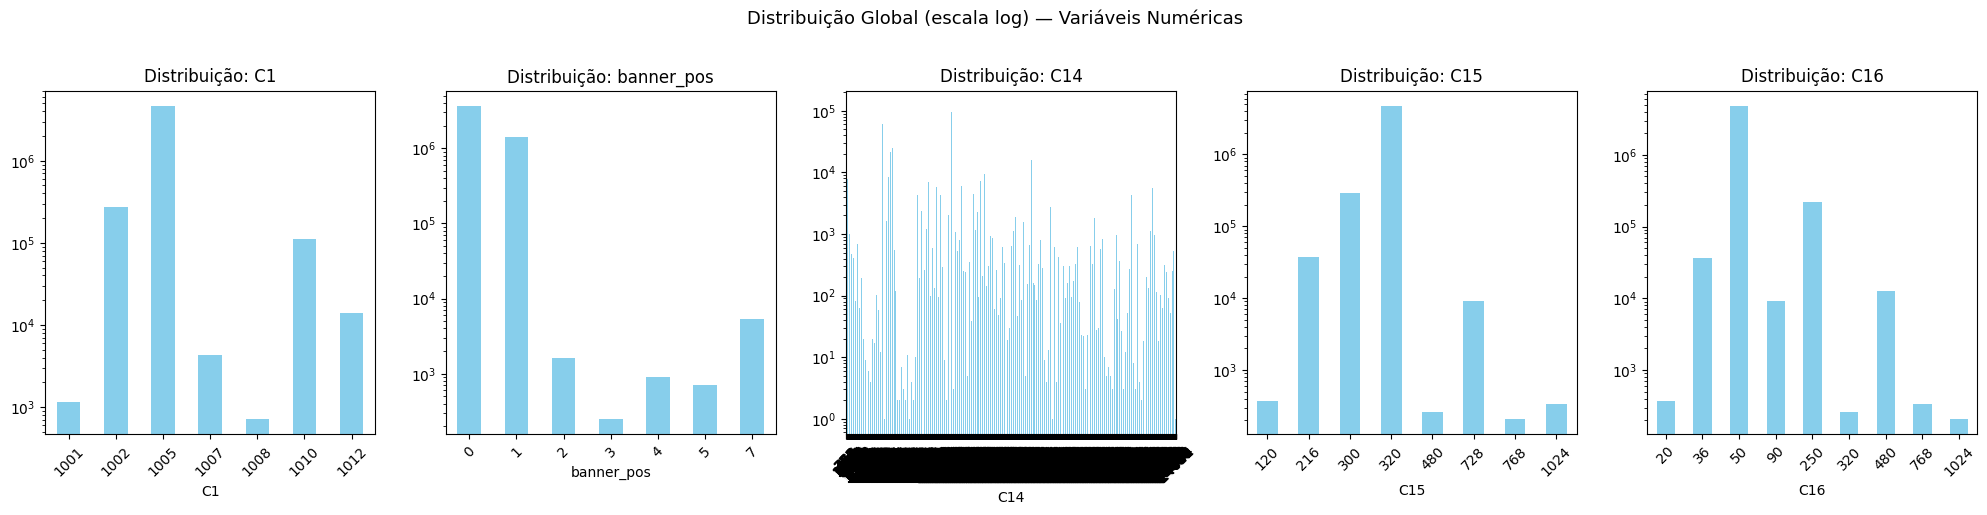

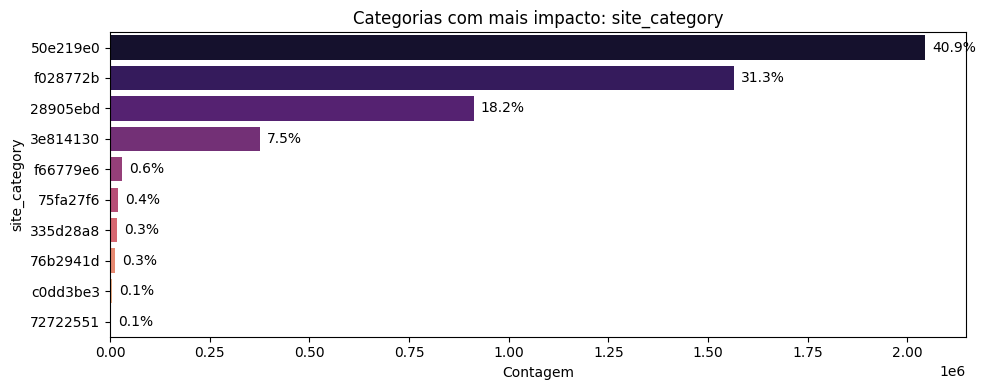

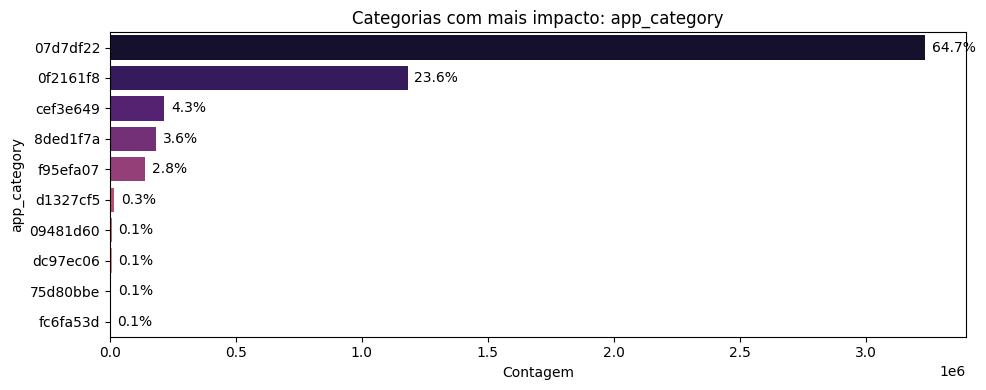

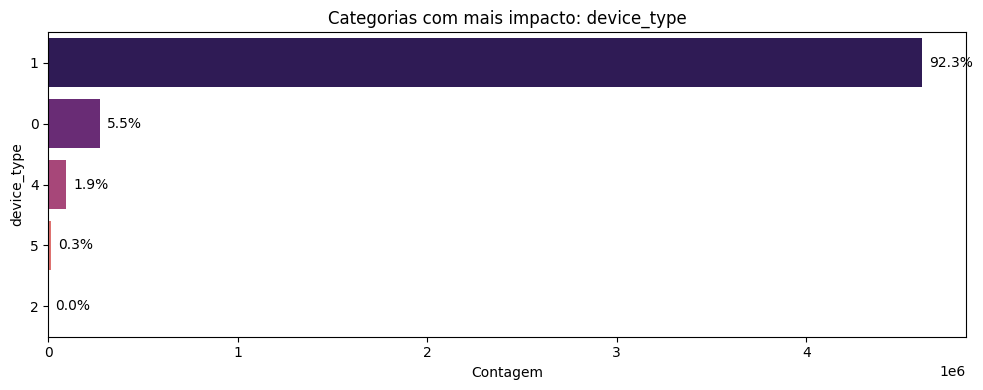

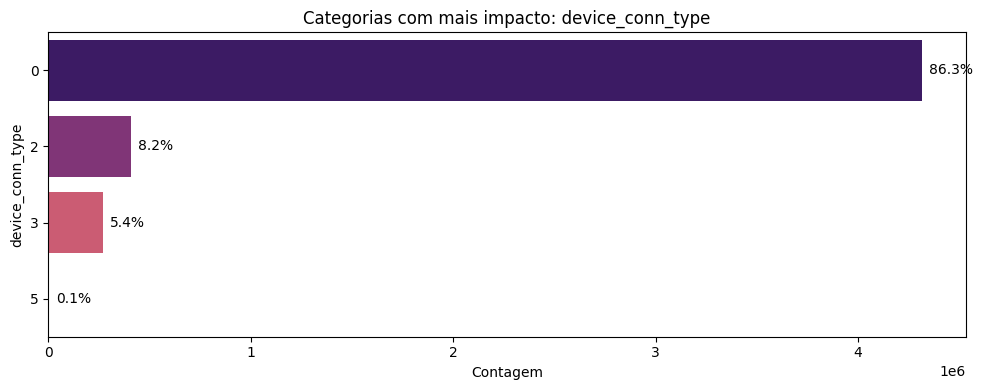

In [8]:
cols_numericas = ['C1', 'banner_pos', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21',
                  'device_type', 'device_conn_type']

# Boxplots
plt.figure(figsize=(20, 5))
cols_box = ['C1', 'banner_pos', 'C14', 'C15', 'C16']
for i, col in enumerate(cols_box):
    plt.subplot(1, 5, i + 1)
    sns.boxplot(y=df[col], color='salmon',
                flierprops={'marker': 'x', 'markerfacecolor': 'red', 'markersize': 3})
    plt.title(f'Outliers: {col}')
plt.suptitle('Identificação de Outliers — Variáveis Numéricas', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Histogramas (escala log) ─────────────────────────────────
plt.figure(figsize=(20, 5))
for i, col in enumerate(cols_box):
    plt.subplot(1, 5, i + 1)
    df[col].value_counts().sort_index().plot(kind='bar', color='skyblue', ax=plt.gca())
    plt.yscale('log')
    plt.title(f'Distribuição: {col}')
    plt.xticks(rotation=45)
plt.suptitle('Distribuição Global (escala log) — Variáveis Numéricas', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Frequência categórica com percentagens 
cols_cat_num = ['site_category', 'app_category', 'device_type', 'device_conn_type']
for col in cols_cat_num:
    plt.figure(figsize=(10, 4))
    top_10 = df[col].astype(str).value_counts().head(10)
    ax = sns.barplot(x=top_10.values, y=top_10.index,
                     hue=top_10.index, palette='magma', legend=False)
    total_col = top_10.sum()
    for p in ax.patches:
        pct = '{:.1f}%'.format(100 * p.get_width() / df[col].count())
        ax.annotate(pct, (p.get_width(), p.get_y() + p.get_height() / 2),
                    xytext=(5, 0), textcoords='offset points', va='center')
    plt.title(f'Categorias com mais impacto: {col}')
    plt.xlabel('Contagem')
    plt.tight_layout()
    plt.show()

### 4.4 Tabela de Outliers por IQR

Cálculo rigoroso do total de outliers por coluna numérica usando o método IQR (Q1 − 1.5×IQR, Q3 + 1.5×IQR).

In [9]:
#  Função utilitária para deteção de outliers 
def calcular_outliers_iqr(df, cols):
    """
    Deteta outliers em variáveis numéricas usando o método do Intervalo
    Interquartil (IQR).

    Um valor é considerado outlier se estiver fora do intervalo:
        [Q1 - 1.5·IQR, Q3 + 1.5·IQR]
    onde IQR = Q3 - Q1 (intervalo entre o 1.º e o 3.º quartis).

    Esta é a regra de Tukey, preferida a critérios baseados em desvio padrão
    porque não assume distribuição Normal — adequada a variáveis discretas/
    desequilibradas como as C14–C21 do Avazu.

    Parâmetros
    ----------
    df : pd.DataFrame
        DataFrame contendo as colunas a analisar.
    cols : list[str]
        Lista de nomes de colunas numéricas a processar.

    Devolve
    -------
    pd.DataFrame com uma linha por coluna analisada, contendo:
        - 'Coluna'     : nome da coluna
        - 'Outliers'   : contagem absoluta de outliers
        - '% Total'    : percentagem de outliers sobre o total de não-nulos
        - 'Limite Inf' : limite inferior calculado (Q1 - 1.5·IQR)
        - 'Limite Sup' : limite superior calculado (Q3 + 1.5·IQR)
    """
    resultados = []
    print(f"{'Coluna':<20} | {'Outliers':>12} | {'% Total':>8} | {'Limite Inf':>12} | {'Limite Sup':>12}")
    print('-' * 72)
    for col in cols:
        if col not in df.columns:
            continue
        # Remover NaN antes de calcular quartis (evita propagação de missing).
        s = df[col].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        # Regra de Tukey: 1.5·IQR para outliers "ligeiros" (3·IQR para extremos).
        li, ls = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((s < li) | (s > ls)).sum()
        pct = n_out / len(s) * 100
        resultados.append({'Coluna': col, 'Outliers': int(n_out),
                            '% Total': round(pct, 2),
                            'Limite Inf': round(li, 2), 'Limite Sup': round(ls, 2)})
        print(f"{col:<20} | {n_out:>12,} | {pct:>7.2f}% | {li:>12.2f} | {ls:>12.2f}")
    return pd.DataFrame(resultados)


# Colunas numéricas relevantes (inclui as anónimas C14–C21 e variáveis técnicas)
cols_num_iqr = ['C1', 'banner_pos', 'C14', 'C15', 'C16', 'C17',
                'C18', 'C19', 'C20', 'C21', 'device_type', 'device_conn_type']

# Aplicar a função e mostrar a tabela consolidada
df_outliers = calcular_outliers_iqr(df, cols_num_iqr)
print("\nTabela resumo:")
display(df_outliers)


Coluna               |     Outliers |  % Total |   Limite Inf |   Limite Sup
------------------------------------------------------------------------
C1                   |      407,113 |    8.14% |      1005.00 |      1005.00
banner_pos           |        7,194 |    0.14% |        -1.50 |         2.50
C14                  |      414,103 |    8.28% |      9459.00 |     29355.00
C15                  |      335,555 |    6.71% |       320.00 |       320.00
C16                  |      282,461 |    5.65% |        50.00 |        50.00
C17                  |      423,361 |    8.47% |       868.50 |      3520.50
C18                  |            0 |    0.00% |        -4.50 |         7.50
C19                  |      900,776 |   18.02% |      -169.00 |       375.00
C20                  |            0 |    0.00% |   -150134.50 |    250221.50
C21                  |      713,315 |   14.27% |       -94.00 |       218.00
device_type          |      386,796 |    7.74% |         1.00 |         1.00
dev

,Coluna,Outliers,% Total,Limite Inf,Limite Sup
0,C1,407113,8.14,1005.0,1005.0
1,banner_pos,7194,0.14,-1.5,2.5
2,C14,414103,8.28,9459.0,29355.0
3,C15,335555,6.71,320.0,320.0
4,C16,282461,5.65,50.0,50.0
5,C17,423361,8.47,868.5,3520.5
6,C18,0,0.00,-4.5,7.5
7,C19,900776,18.02,-169.0,375.0
8,C20,0,0.00,-150134.5,250221.5
9,C21,713315,14.27,-94.0,218.0


### 4.5 Matriz de Correlação de Pearson

Heatmap da correlação entre todas as variáveis numéricas, com destaque para as correlações com a variável alvo `click`. Identifica também pares com multicolinearidade elevada (|r| > 0.85) — candidatos a remoção no pré-processamento.

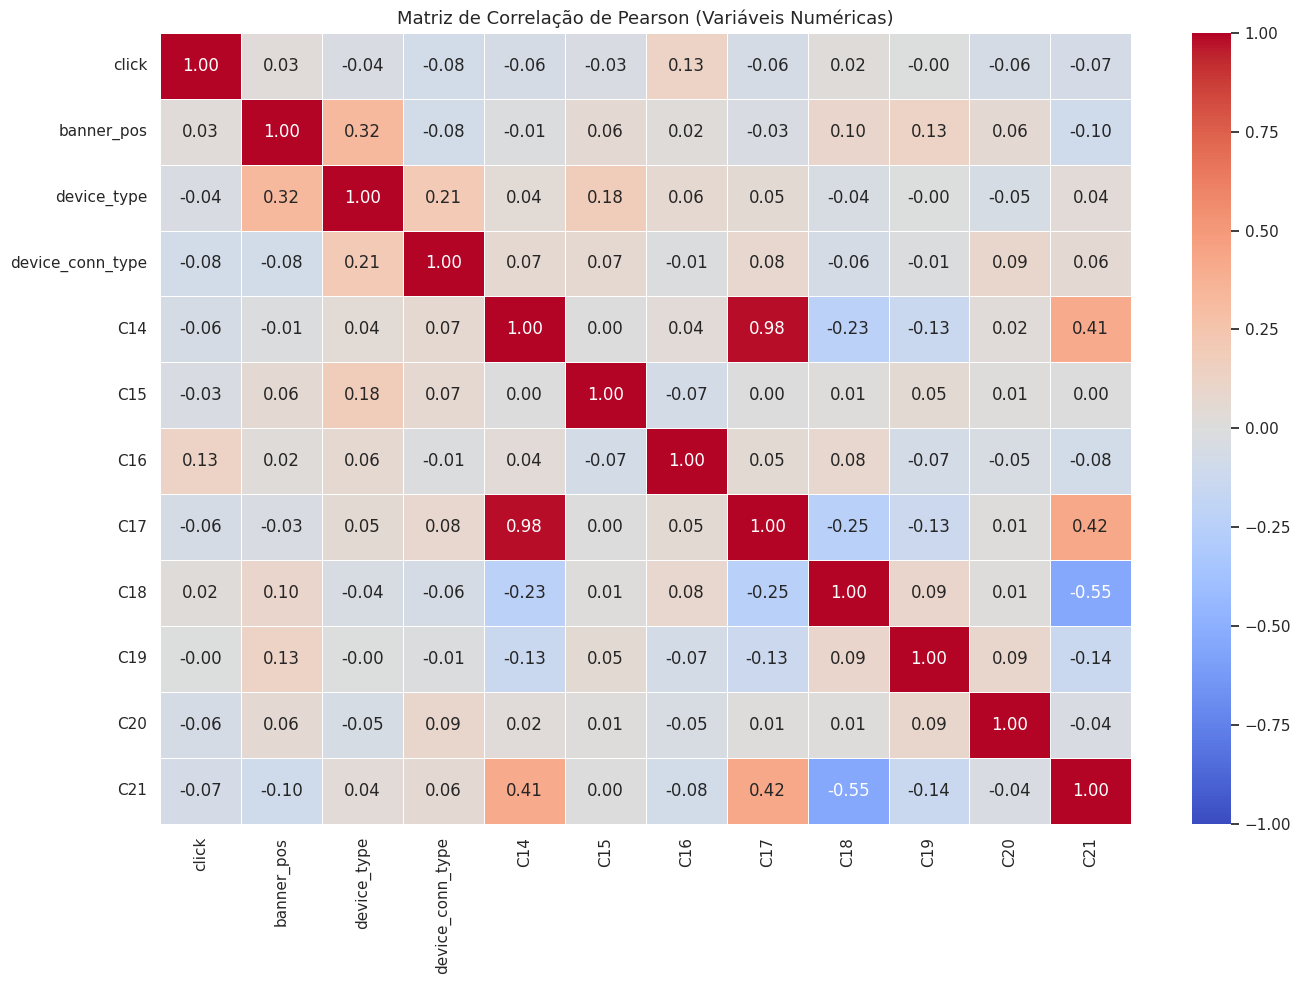

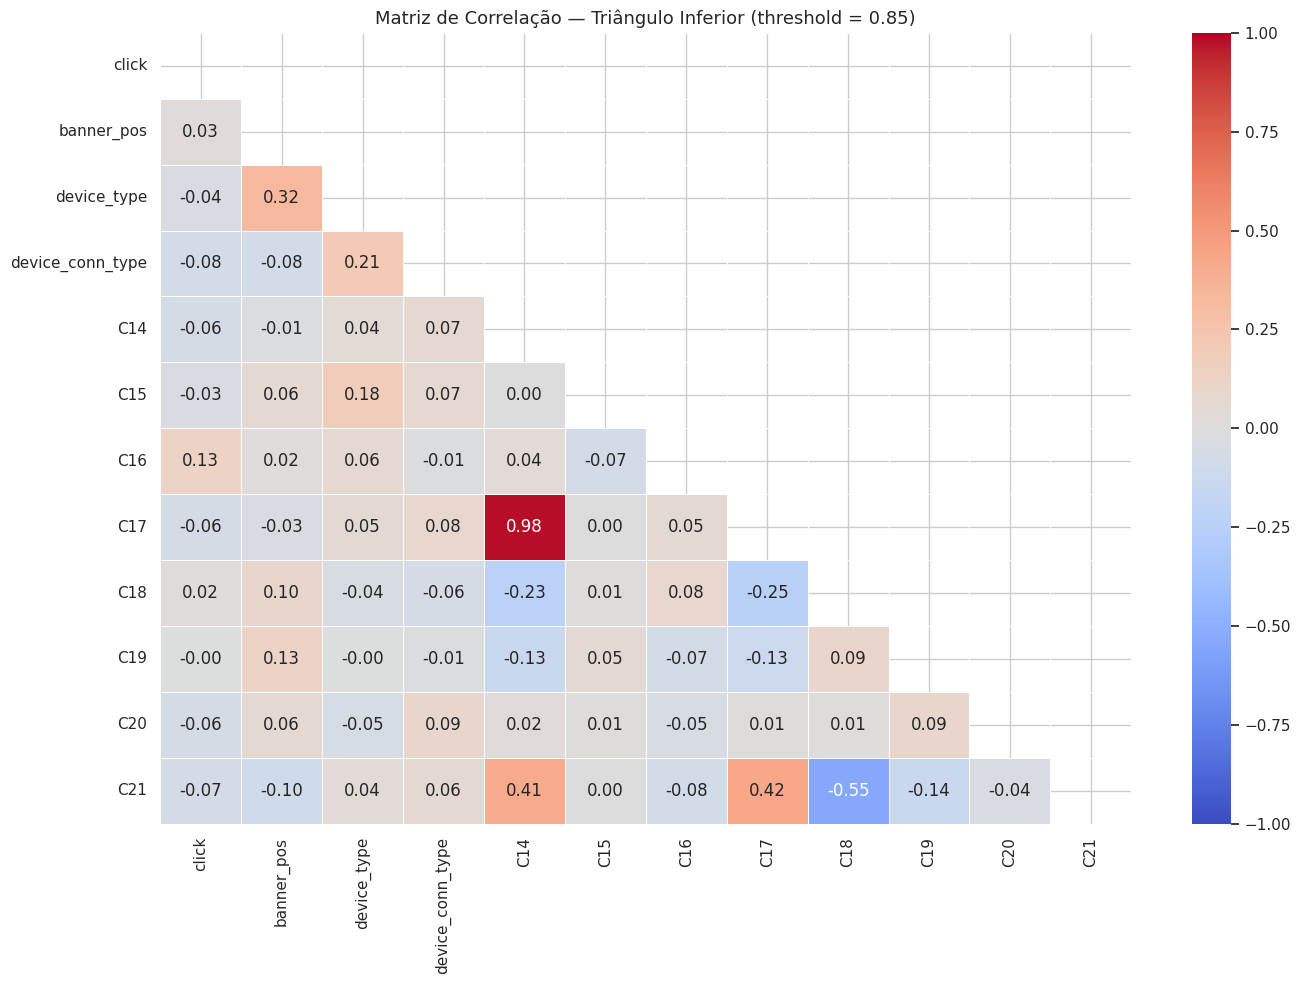

Correlações com a variável alvo ('click'):
  C16                      : +0.1303
  device_conn_type         : -0.0832
  C21                      : -0.0698
  C14                      : -0.0608
  C20                      : -0.0580
  C17                      : -0.0561
  device_type              : -0.0374
  C15                      : -0.0325
  banner_pos               : +0.0263
  C18                      : +0.0216
  C19                      : -0.0038

Pares com |correlação| > 0.85 (multicolinearidade):
  C14  ↔  C17  →  r = 0.9769


,Var A,Var B,r
0,C14,C17,0.9769


In [10]:
#  Análise de correlações entre variáveis numéricas
sns.set_theme(style='whitegrid')

# Conjunto de variáveis a incluir na matriz. Incluímos `click` para ver
# diretamente a correlação (linear) de cada feature com a variável alvo.
# Excluímos as colunas puramente categóricas (site_id, app_id, ...) por não
# serem significativas em correlação de Pearson antes do encoding.
cols_to_correlate = ['click', 'banner_pos', 'device_type', 'device_conn_type',
                     'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21']

# Matriz de correlação de Pearson (linear) entre todas as colunas selecionadas
corr_df = df[cols_to_correlate].corr()

# ── Visualização 1: heatmap completo ──────────────────────────────
# Mostra a matriz inteira (inclui redundância entre triângulo superior/inferior).
plt.figure(figsize=(14, 10))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, vmin=-1, vmax=1, center=0)
plt.title('Matriz de Correlação de Pearson (Variáveis Numéricas)', fontsize=13)
plt.tight_layout()
plt.show()

# ── Visualização 2: heatmap triangular (sem duplicados) ───────────
# np.triu cria uma máscara para esconder o triângulo superior, que é redundante
# por simetria (Corr(A,B) = Corr(B,A)).
mask = np.triu(np.ones_like(corr_df.values, dtype=bool))
plt.figure(figsize=(14, 10))
sns.heatmap(corr_df, mask=mask, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.4, vmin=-1, vmax=1, center=0)
plt.title('Matriz de Correlação — Triângulo Inferior (threshold = 0.85)', fontsize=13)
plt.tight_layout()
plt.show()

# ── Interpretação 1: correlações com a variável alvo ──────────────
# Ordenadas por valor absoluto (relevância, não sinal).
print("Correlações com a variável alvo ('click'):")
corr_alvo = corr_df['click'].drop('click').sort_values(key=abs, ascending=False)
for col, val in corr_alvo.items():
    print(f"  {col:<25}: {val:+.4f}")

# ── Interpretação 2: deteção de multicolinearidade ────────────────
# Pares com |correlação| > 0.85 são candidatos a remoção no pré-processamento,
# pois introduzem redundância informativa e podem instabilizar regressões.
THRESHOLD = 0.85
print(f"\nPares com |correlação| > {THRESHOLD} (multicolinearidade):")
pares = []
cols_list = list(corr_df.columns)
for i in range(len(cols_list)):
    for j in range(i+1, len(cols_list)):
        r = corr_df.iloc[i, j]
        if abs(r) > THRESHOLD:
            pares.append({'Var A': cols_list[i], 'Var B': cols_list[j], 'r': round(r, 4)})
            print(f"  {cols_list[i]}  ↔  {cols_list[j]}  →  r = {r:.4f}")
if not pares:
    print("  Nenhum par acima do threshold.")
else:
    display(pd.DataFrame(pares).sort_values('r', key=abs, ascending=False))


### 4.5b Gráficos de Dispersão — Relação entre Atributos e Variável Alvo

Scatter plots para visualizar a relação directa entre variáveis numéricas e a taxa de clique (`click`). Como `click` é binário (0/1), usamos *jitter* no eixo Y e transparência para revelar a densidade.

Para variáveis discretas de baixa cardinalidade, usamos gráficos de *mean CTR* com intervalos de confiança — mais informativos do que scatter com sobreposição total.


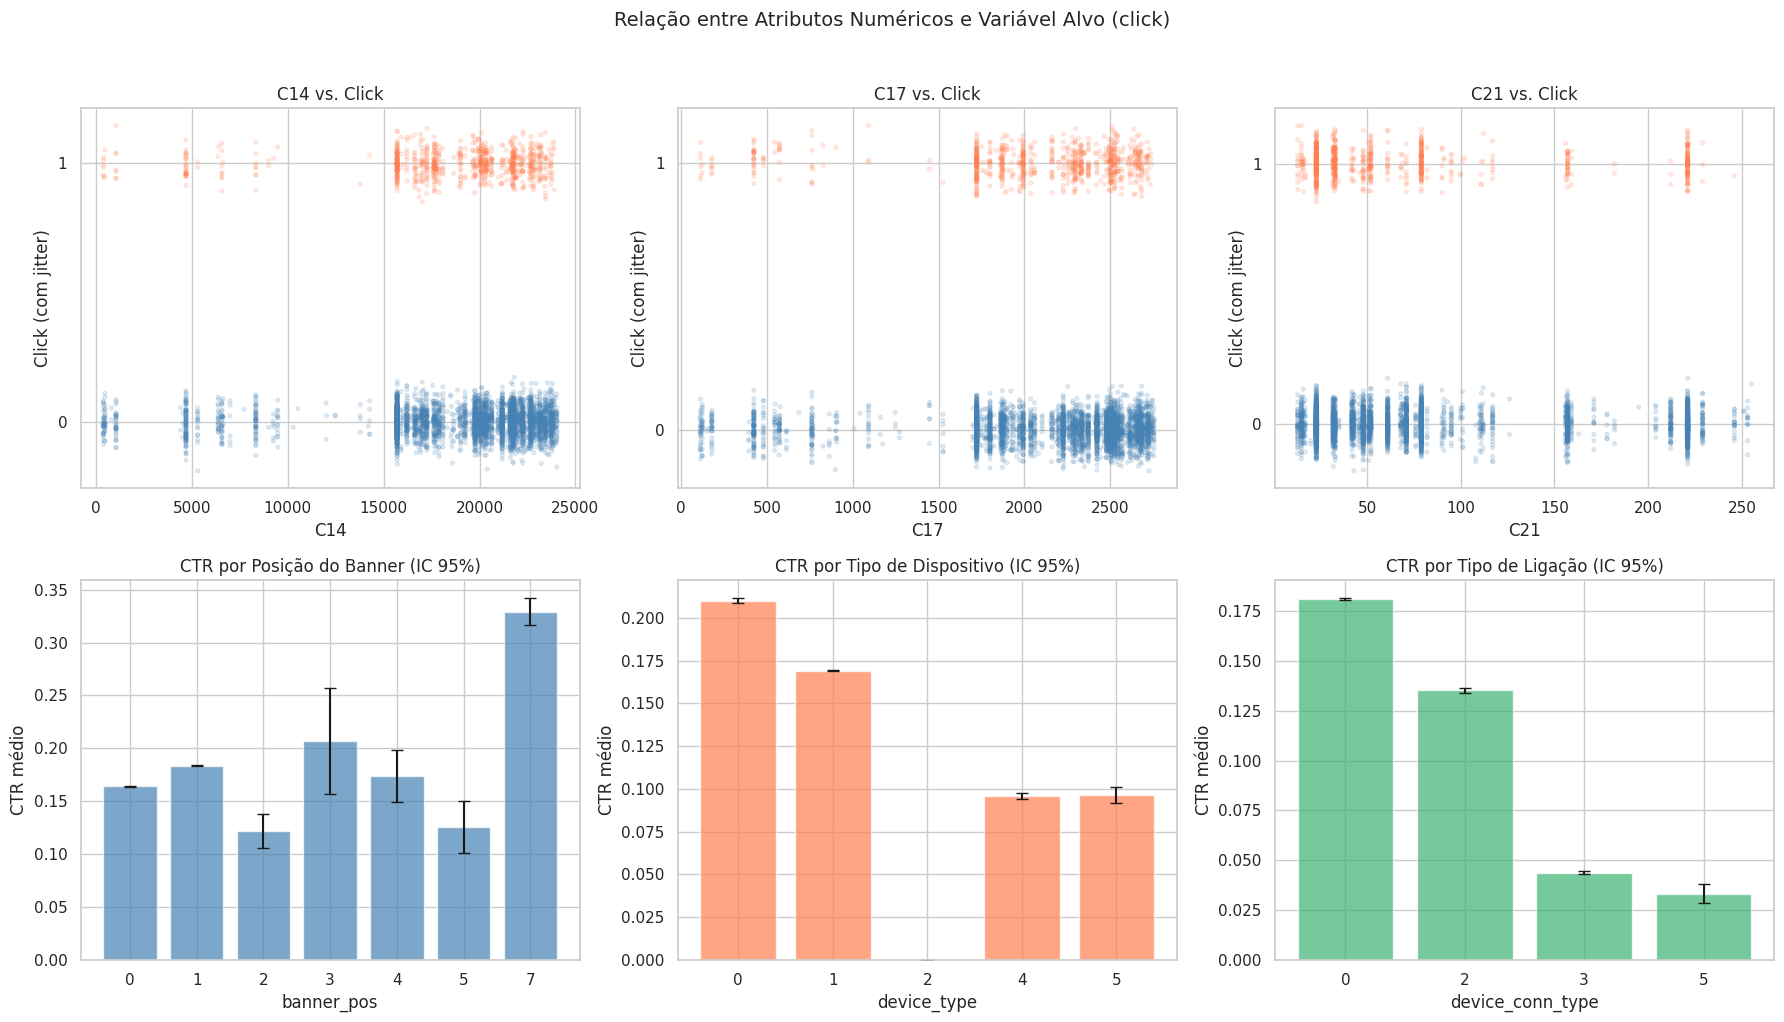

Scatter plots gerados para M2 Aula 8.


In [11]:
# ── [M2 Aula 8] Gráficos de Dispersão — Atributos vs. Variável Alvo ──
# A professora pede explicitamente scatter plots. Como click é binário,
# usamos abordagens adaptadas para extrair valor visual.

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ── Scatter 1: C14 vs Click (com jitter) ──────────────────────
ax = axes[0, 0]
sample_scatter = df.sample(n=min(5000, len(df)), random_state=42)
ax.scatter(sample_scatter['C14'],
           sample_scatter['click'] + np.random.normal(0, 0.05, len(sample_scatter)),
           alpha=0.15, s=8, c=sample_scatter['click'].map({0: 'steelblue', 1: 'coral'}))
ax.set_xlabel('C14')
ax.set_ylabel('Click (com jitter)')
ax.set_title('C14 vs. Click')
ax.set_yticks([0, 1])

# ── Scatter 2: C17 vs Click (com jitter) ──────────────────────
ax = axes[0, 1]
ax.scatter(sample_scatter['C17'],
           sample_scatter['click'] + np.random.normal(0, 0.05, len(sample_scatter)),
           alpha=0.15, s=8, c=sample_scatter['click'].map({0: 'steelblue', 1: 'coral'}))
ax.set_xlabel('C17')
ax.set_ylabel('Click (com jitter)')
ax.set_title('C17 vs. Click')
ax.set_yticks([0, 1])

# ── Scatter 3: C21 vs Click ───────────────────────────────────
ax = axes[0, 2]
ax.scatter(sample_scatter['C21'],
           sample_scatter['click'] + np.random.normal(0, 0.05, len(sample_scatter)),
           alpha=0.15, s=8, c=sample_scatter['click'].map({0: 'steelblue', 1: 'coral'}))
ax.set_xlabel('C21')
ax.set_ylabel('Click (com jitter)')
ax.set_title('C21 vs. Click')
ax.set_yticks([0, 1])

# ── Mean CTR por banner_pos com IC ────────────────────────────
ax = axes[1, 0]
ctr_bp = df.groupby('banner_pos')['click'].agg(['mean', 'count', 'std']).reset_index()
ctr_bp['se'] = ctr_bp['std'] / np.sqrt(ctr_bp['count'])
ax.bar(ctr_bp['banner_pos'].astype(str), ctr_bp['mean'], yerr=1.96*ctr_bp['se'],
       color='steelblue', alpha=0.7, capsize=4)
ax.set_xlabel('banner_pos')
ax.set_ylabel('CTR médio')
ax.set_title('CTR por Posição do Banner (IC 95%)')

# ── Mean CTR por device_type com IC ───────────────────────────
ax = axes[1, 1]
ctr_dt = df.groupby('device_type')['click'].agg(['mean', 'count', 'std']).reset_index()
ctr_dt['se'] = ctr_dt['std'] / np.sqrt(ctr_dt['count'])
ax.bar(ctr_dt['device_type'].astype(str), ctr_dt['mean'], yerr=1.96*ctr_dt['se'],
       color='coral', alpha=0.7, capsize=4)
ax.set_xlabel('device_type')
ax.set_ylabel('CTR médio')
ax.set_title('CTR por Tipo de Dispositivo (IC 95%)')

# ── Mean CTR por device_conn_type com IC ──────────────────────
ax = axes[1, 2]
ctr_dc = df.groupby('device_conn_type')['click'].agg(['mean', 'count', 'std']).reset_index()
ctr_dc['se'] = ctr_dc['std'] / np.sqrt(ctr_dc['count'])
ax.bar(ctr_dc['device_conn_type'].astype(str), ctr_dc['mean'], yerr=1.96*ctr_dc['se'],
       color='mediumseagreen', alpha=0.7, capsize=4)
ax.set_xlabel('device_conn_type')
ax.set_ylabel('CTR médio')
ax.set_title('CTR por Tipo de Ligação (IC 95%)')

plt.suptitle('Relação entre Atributos Numéricos e Variável Alvo (click)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('Scatter plots gerados para M2 Aula 8.')


### 4.6 Análise Bivariada — CTR por Variável

Taxa de cliques (CTR) calculada directamente na amostra para as variáveis mais relevantes: hora do dia, posição do banner, tipo de dispositivo, tipo de ligação, categoria de site e categoria de app.

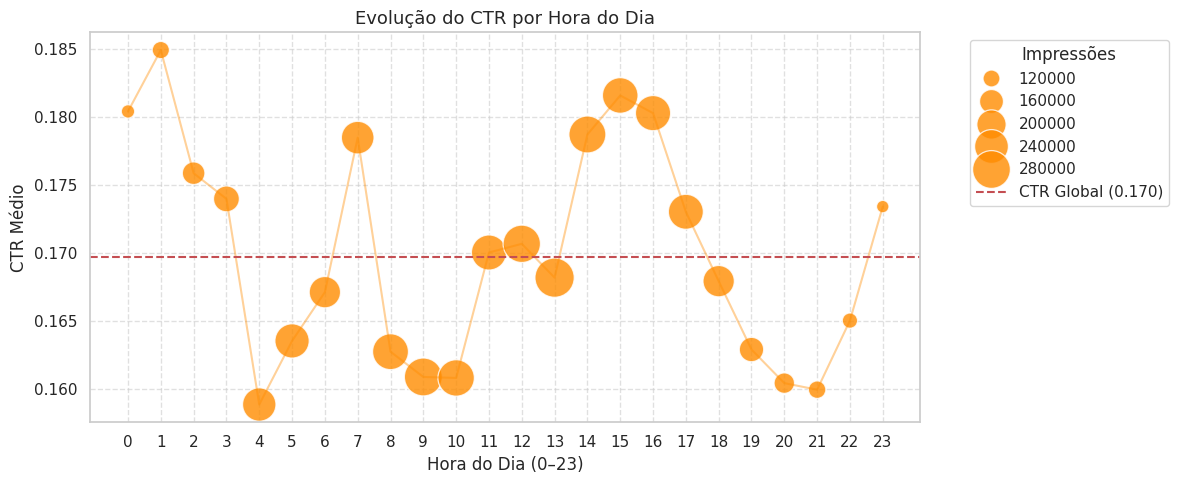

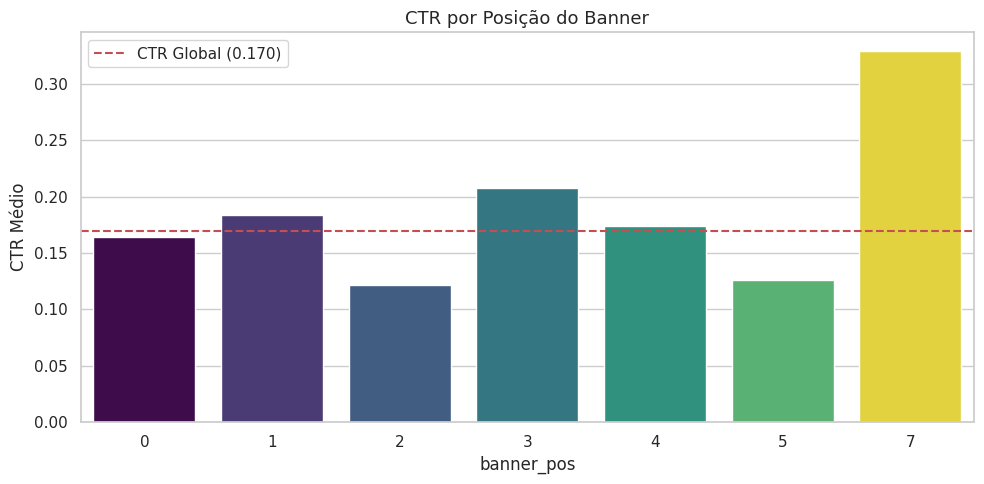

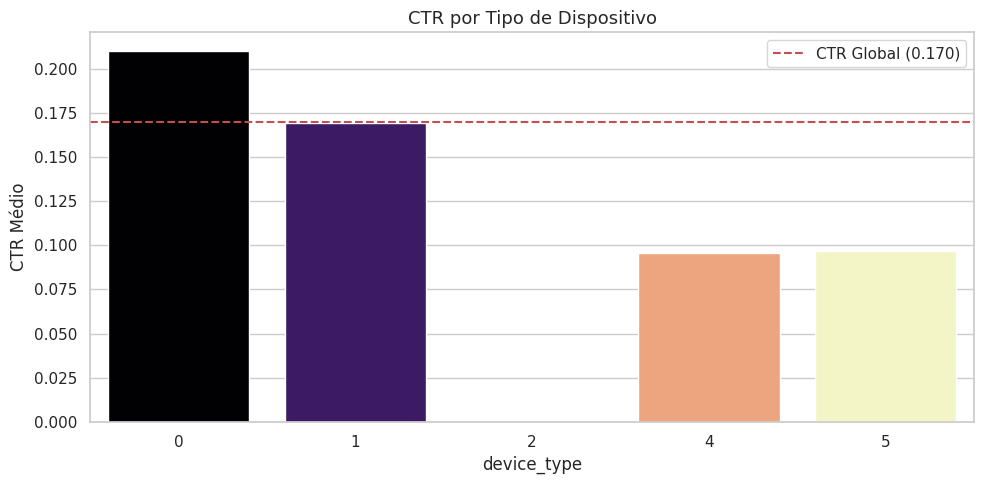

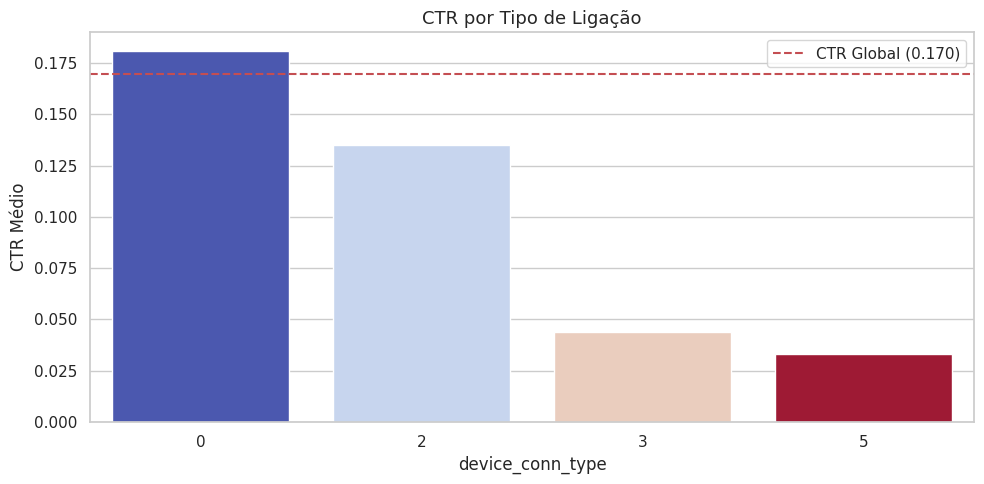

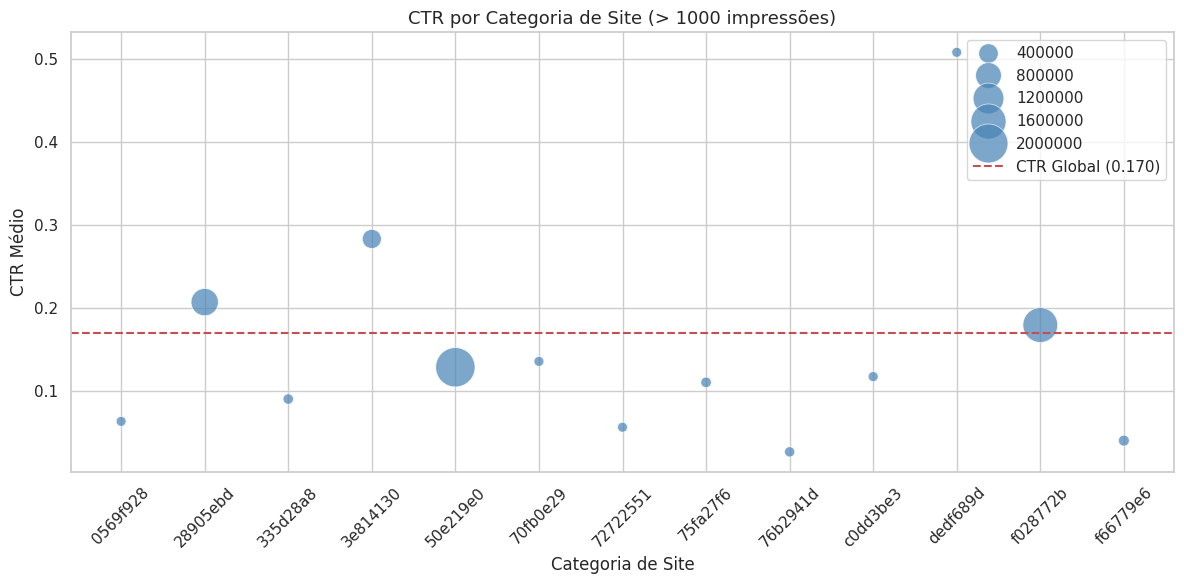

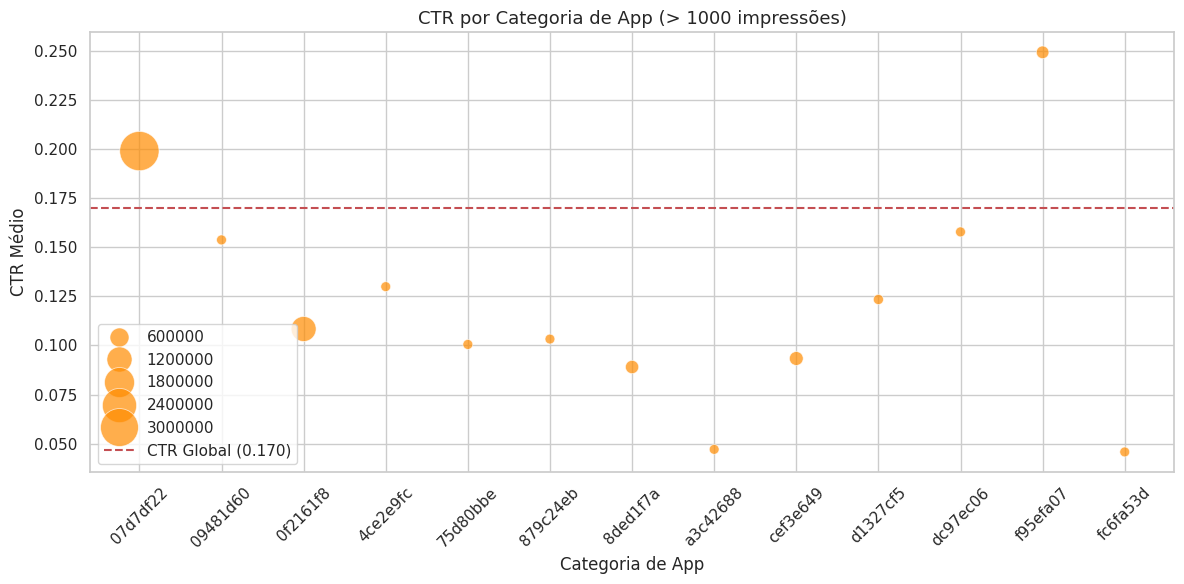

Análise bivariada CTR concluída.


In [12]:
# ── Preparar coluna hora_do_dia temporária ──────────────────
df_eda = df.copy()
df_eda['hora_do_dia'] = df_eda['hour'] % 100

global_ctr = df_eda['click'].mean()

def plot_ctr_bar(stats_df, x_col, title, palette='viridis'):
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=stats_df, x=x_col, y='CTR',
                     hue=x_col, palette=palette, legend=False)
    plt.axhline(global_ctr, color='r', linestyle='--',
                label=f'CTR Global ({global_ctr:.3f})')
    plt.title(title, fontsize=13)
    plt.xlabel(x_col)
    plt.ylabel('CTR Médio')
    plt.legend()
    plt.tight_layout()
    plt.show()

# ── CTR por Hora do Dia ─────────────────────────────────────
df_hour = df_eda.groupby('hora_do_dia')['click'].agg(
    clicks='sum', impressions='count').reset_index()
df_hour['CTR'] = df_hour['clicks'] / df_hour['impressions']
df_hour.sort_values('hora_do_dia', inplace=True)

plt.figure(figsize=(12, 5))
sns.scatterplot(data=df_hour, x='hora_do_dia', y='CTR',
                size='impressions', sizes=(80, 800), color='darkorange', alpha=0.8)
sns.lineplot(data=df_hour, x='hora_do_dia', y='CTR', color='darkorange', alpha=0.4)
plt.axhline(global_ctr, color='r', linestyle='--', label=f'CTR Global ({global_ctr:.3f})')
plt.title('Evolução do CTR por Hora do Dia', fontsize=13)
plt.xlabel('Hora do Dia (0–23)')
plt.ylabel('CTR Médio')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Impressões', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ── CTR por banner_pos ──────────────────────────────────────
df_banner = df_eda.groupby('banner_pos')['click'].agg(
    clicks='sum', impressions='count').reset_index()
df_banner['CTR'] = df_banner['clicks'] / df_banner['impressions']
plot_ctr_bar(df_banner, 'banner_pos', 'CTR por Posição do Banner', 'viridis')

# ── CTR por device_type ─────────────────────────────────────
df_dev = df_eda.groupby('device_type')['click'].agg(
    clicks='sum', impressions='count').reset_index()
df_dev['CTR'] = df_dev['clicks'] / df_dev['impressions']
plot_ctr_bar(df_dev, 'device_type', 'CTR por Tipo de Dispositivo', 'magma')

# ── CTR por device_conn_type ────────────────────────────────
df_conn = df_eda.groupby('device_conn_type')['click'].agg(
    clicks='sum', impressions='count').reset_index()
df_conn['CTR'] = df_conn['clicks'] / df_conn['impressions']
plot_ctr_bar(df_conn, 'device_conn_type', 'CTR por Tipo de Ligação', 'coolwarm')

# ── CTR por site_category ───────────────────────────────────
df_site = df_eda.groupby('site_category')['click'].agg(
    clicks='sum', impressions='count').reset_index()
df_site['CTR'] = df_site['clicks'] / df_site['impressions']
df_site = df_site[df_site['impressions'] > 1000]

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_site, x='site_category', y='CTR',
                size='impressions', sizes=(50, 800), alpha=0.7, color='steelblue')
plt.axhline(global_ctr, color='r', linestyle='--', label=f'CTR Global ({global_ctr:.3f})')
plt.title('CTR por Categoria de Site (> 1000 impressões)', fontsize=13)
plt.xlabel('Categoria de Site')
plt.ylabel('CTR Médio')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# ── CTR por app_category ────────────────────────────────────
df_app = df_eda.groupby('app_category')['click'].agg(
    clicks='sum', impressions='count').reset_index()
df_app['CTR'] = df_app['clicks'] / df_app['impressions']
df_app = df_app[df_app['impressions'] > 1000]

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_app, x='app_category', y='CTR',
                size='impressions', sizes=(50, 800), alpha=0.7, color='darkorange')
plt.axhline(global_ctr, color='r', linestyle='--', label=f'CTR Global ({global_ctr:.3f})')
plt.title('CTR por Categoria de App (> 1000 impressões)', fontsize=13)
plt.xlabel('Categoria de App')
plt.ylabel('CTR Médio')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

del df_eda
print('Análise bivariada CTR concluída.')

### 4.8 Três Conclusões Visuais da Análise Exploratória

> **[M2 Aula 8]** As três observações mais relevantes extraídas dos gráficos das secções 4.1–4.7:

**Conclusão 1 — Forte desequilíbrio na variável alvo.**  
O gráfico da secção 4.1 confirma que apenas ~17% dos registos têm `click=1`. Este desequilíbrio condiciona toda a estratégia de modelação: impõe o uso de AUC-ROC como métrica principal (em vez de Accuracy), o recurso a `class_weight='balanced'` nos modelos lineares e `scale_pos_weight` no XGBoost, e a estratificação obrigatória em todas as divisões de dados.

**Conclusão 2 — O CTR varia significativamente com a hora do dia e com a posição do banner.**  
Os gráficos das secções 4.6 e 4.5b mostram que: (a) o CTR apresenta variação temporal com picos e vales ao longo das 24h, justificando a criação da feature `hora_do_dia`; (b) a posição `banner_pos=7` tem CTR muito acima da média global, enquanto `banner_pos=0` (a mais frequente) tem CTR abaixo. Isto sugere que a posição do anúncio é um preditor relevante.

**Conclusão 3 — As colunas anónimas C15 e C16 apresentam padrões compatíveis com dimensões de banners.**  
A análise de valores únicos (secção 5) e a correlação positiva de `banner_area = C15 × C16` com o CTR sugerem que estas colunas representam largura e altura do banner em pixels. Esta hipótese sustenta a criação da feature `banner_area` e da derivada `visibilidade_anuncio`.


### 4.7 Missing Values Mascarados — Antes e Depois da Limpeza

Comparação visual do impacto da imputação por moda na coluna C20 (que usa -1 como código de valor em falta).

=== ANTES DA LIMPEZA ===
Valores -1 em C20: 2,344,248
Distribuição C20 (top 5):
C20
-1         2344248
 100084     301520
 100148     221366
 100111     212930
 100077     195121
Name: count, dtype: int64

=== DEPOIS DA LIMPEZA ===
Valores -1 em C20: 0
Distribuição C20 (top 5):
C20
100084    2645768
100148     221366
100111     212930
100077     195121
100075     191012
Name: count, dtype: int64



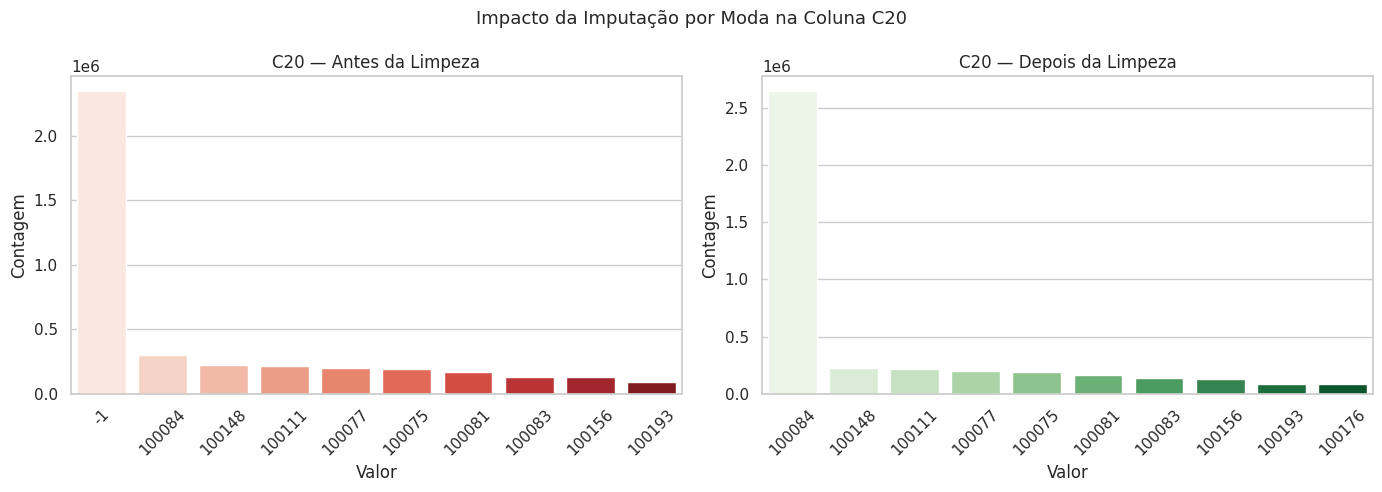

In [13]:
moda_c20 = df['C20'][df['C20'] != -1].mode()[0]

print('=== ANTES DA LIMPEZA ===')
print(f"Valores -1 em C20: {(df['C20'] == -1).sum():,}")
print(f"Distribuição C20 (top 5):\n{df['C20'].value_counts().head()}\n")

df_clean_demo = df.copy()
df_clean_demo['C20'] = df_clean_demo['C20'].replace(-1, pd.NA).fillna(moda_c20)

print('=== DEPOIS DA LIMPEZA ===')
print(f"Valores -1 em C20: {(df_clean_demo['C20'] == -1).sum():,}")
print(f"Distribuição C20 (top 5):\n{df_clean_demo['C20'].value_counts().head()}\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cb = df['C20'].value_counts().head(10)
sns.barplot(x=cb.index.astype(str), y=cb.values,
            hue=cb.index.astype(str), palette='Reds', ax=axes[0], legend=False)
axes[0].set_title('C20 — Antes da Limpeza')
axes[0].set_xlabel('Valor')
axes[0].set_ylabel('Contagem')
axes[0].tick_params(axis='x', rotation=45)

ca = df_clean_demo['C20'].value_counts().head(10)
sns.barplot(x=ca.index.astype(str), y=ca.values,
            hue=ca.index.astype(str), palette='Greens', ax=axes[1], legend=False)
axes[1].set_title('C20 — Depois da Limpeza')
axes[1].set_xlabel('Valor')
axes[1].set_ylabel('Contagem')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Impacto da Imputação por Moda na Coluna C20', fontsize=13)
plt.tight_layout()
plt.show()
del df_clean_demo

## 5. Pré-Processamento e Feature Engineering

Criação de novas variáveis, imputação de missing values mascarados, Label Encoding das colunas categóricas, remoção de colunas com multicolinearidade elevada (|r| > 0.95) e verificação da correlação das novas features.

In [14]:

from sklearn.preprocessing import StandardScaler

df_proc = df.copy()

# Verificação das suposições sobre C15 e C16 
# Antes de criar banner_area, verificamos e documentamos a hipótese de que
# C15 e C16 representam, respetivamente, largura e altura do banner (em pixels).
# As colunas C14–C21 são anónimas no dataset Avazu, portanto esta é uma suposição
# que o leitor do notebook deve conhecer.
print('Valores únicos de C15:', sorted(df_proc['C15'].unique())[:15])
print('Valores únicos de C16:', sorted(df_proc['C16'].unique())[:15])
print("""
→ Se os valores forem compatíveis com dimensões típicas de banners em pixels
  (120, 216, 300, 320, 480, 728, 768, 1024, ...) a hipótese fica reforçada.
→ Caso contrário, banner_area deve ser interpretada apenas como a interação
  C15×C16, sem significado geométrico.
""")

#  IMPUTAÇÃO SISTEMÁTICA DE MISSING MASCARADOS
# Aqui, aplicamos o mesmo tratamento a todas as colunas C14–C21 em que a percentagem de -1 ultrapasse um threshold.
THRESHOLD_PCT = 1.0  # colunas com < 1% de -1 são consideradas limpas
print('Imputação por moda (substituindo -1) nas colunas com ≥ 1% de valores mascarados:')
for col in [f'C{i}' for i in range(14, 22)]:
    if col not in df_proc.columns:
        continue
    pct_neg = (df_proc[col] == -1).mean() * 100
    if pct_neg >= THRESHOLD_PCT:
        moda = int(df_proc[col][df_proc[col] != -1].mode()[0])
        df_proc[col] = df_proc[col].replace(-1, pd.NA).fillna(moda).astype(int)
        print(f'  {col}: {pct_neg:5.2f}% de -1 imputados pela moda ({moda})')
    else:
        print(f'  {col}: {pct_neg:5.2f}% de -1 — abaixo do threshold, sem imputação')

#  FEATURE ENGINEERING 
# hora_do_dia — extraída de 'hour' (formato YYMMDDhh)
df_proc['hora_do_dia'] = df_proc['hour'] % 100

# banner_area — largura × altura do banner (ver nota C15/C16 acima)
df_proc['banner_area'] = df_proc['C15'] * df_proc['C16']

# [CORRECAO 2.3] visibilidade_anuncio
# Versão original: banner_pos / log1p(banner_area) — problema: banner_pos é
# frequentemente 0 (posição 'top'), o que zera toda a feature para a maioria
# dos registos e destrói a sua variância. Usamos (banner_pos + 1) para preservar
# informação mesmo quando a posição é 0.
df_proc['visibilidade_anuncio'] = (df_proc['banner_pos'] + 1) / np.log1p(df_proc['banner_area'])
frac_zeros = (df_proc['visibilidade_anuncio'] == 0).mean() * 100
print(f"\n  Fracção de zeros em visibilidade_anuncio: {frac_zeros:.2f}%  (deve ser baixa)")

# Remover coluna 'hour' original
df_proc.drop(columns=['hour'], inplace=True)
print('\n  Features criadas: hora_do_dia, banner_area, visibilidade_anuncio')

#  CORRELAÇÃO DAS NOVAS VARIÁVEIS COM CLICK 
novas_vars = ['hora_do_dia', 'banner_area', 'visibilidade_anuncio']
print("\nCorrelação das novas variáveis com 'click':")
for v in novas_vars:
    r = df_proc[v].corr(df_proc['click'])
    print(f"  {v:<25}: {r:+.4f}")

# REMOVER COLUNAS NÃO PREDITIVAS 
cols_to_remove = ['id', 'device_id', 'device_ip']
df_proc.drop(columns=[c for c in cols_to_remove if c in df_proc.columns], inplace=True)
print(f'\n  Colunas removidas (não preditivas): {cols_to_remove}')

# Encoding de categóricas é feito APÓS o split.
# As colunas object permanecem como object até essa altura.
cat_pendentes = df_proc.select_dtypes(include='object').columns.tolist()
print(f'\n  Colunas categóricas pendentes de encoding (a fazer após split): {cat_pendentes}')


print(f'\nDataset intermédio: {df_proc.shape[0]:,} registos × {df_proc.shape[1]} colunas')
print('(Encoding + remoção de multicolinearidade ocorrem após o split.)')


Valores únicos de C15: [np.int64(120), np.int64(216), np.int64(300), np.int64(320), np.int64(480), np.int64(728), np.int64(768), np.int64(1024)]
Valores únicos de C16: [np.int64(20), np.int64(36), np.int64(50), np.int64(90), np.int64(250), np.int64(320), np.int64(480), np.int64(768), np.int64(1024)]

→ Se os valores forem compatíveis com dimensões típicas de banners em pixels
  (120, 216, 300, 320, 480, 728, 768, 1024, ...) a hipótese fica reforçada.
→ Caso contrário, banner_area deve ser interpretada apenas como a interação
  C15×C16, sem significado geométrico.

Imputação por moda (substituindo -1) nas colunas com ≥ 1% de valores mascarados:
  C14:  0.00% de -1 — abaixo do threshold, sem imputação
  C15:  0.00% de -1 — abaixo do threshold, sem imputação
  C16:  0.00% de -1 — abaixo do threshold, sem imputação
  C17:  0.00% de -1 — abaixo do threshold, sem imputação
  C18:  0.00% de -1 — abaixo do threshold, sem imputação
  C19:  0.00% de -1 — abaixo do threshold, sem imputação
  C20:

## 6. Inspeção do Dataset Processado

In [15]:

print('DIMENSÃO')
print(f'  {df_proc.shape[0]:,} registos × {df_proc.shape[1]} colunas')

print('\nPRIMEIRAS 5 LINHAS')
display(df_proc.head())

print('\nTIPOS DE DADOS')
display(df_proc.dtypes.to_frame('Tipo'))

print('\nVALORES NULOS')
nc = df_proc.isnull().sum()
display(nc.to_frame('Nulos'))
print(f'Total de valores nulos: {int(nc.sum())}')

print('\nESTATÍSTICAS NUMÉRICAS')
display(df_proc.describe())

DIMENSÃO
  5,000,000 registos × 23 colunas

PRIMEIRAS 5 LINHAS


,click,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_model,...,C15,C16,C17,C18,C19,C20,C21,hora_do_dia,banner_area,visibilidade_anuncio
0,0,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,8a4875bd,...,320,50,1722,0,35,100084,79,0,16000,0.103301
1,0,1002,0,84c7ba46,c4e18dd6,50e219e0,ecad2386,7801e8d9,07d7df22,373ecbe6,...,320,50,2496,3,167,100191,23,0,16000,0.103301
2,0,1005,0,543a539e,c7ca3108,3e814130,ecad2386,7801e8d9,07d7df22,607e78f2,...,320,50,2333,0,39,100084,157,0,16000,0.103301
3,1,1002,0,84c7ba46,c4e18dd6,50e219e0,ecad2386,7801e8d9,07d7df22,cf19f7f7,...,320,50,2446,3,171,100228,156,0,16000,0.103301
4,1,1005,0,85f751fd,c4e18dd6,50e219e0,0acbeaa3,45a51db4,f95efa07,68b900d9,...,320,50,2161,0,35,100034,157,0,16000,0.103301



TIPOS DE DADOS


,Tipo
click,int64
C1,int64
banner_pos,int64
site_id,object
site_domain,object
site_category,object
app_id,object
app_domain,object
app_category,object
device_model,object



VALORES NULOS


,Nulos
click,0
C1,0
banner_pos,0
site_id,0
site_domain,0
site_category,0
app_id,0
app_domain,0
app_category,0
device_model,0


Total de valores nulos: 0

ESTATÍSTICAS NUMÉRICAS


,click,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21,hora_do_dia,banner_area,visibilidade_anuncio
count,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06
mean,1.697188e-01,1.004968e+03,2.881012e-01,1.015408e+00,3.300478e-01,1.884259e+04,3.188800e+02,6.005896e+01,2.112686e+03,1.432106e+00,2.272310e+02,1.000991e+05,8.340489e+01,1.127767e+01,1.908003e+04,1.322940e-01
std,3.753856e-01,1.095621e+00,5.057768e-01,5.279241e-01,8.530219e-01,4.958047e+03,2.123737e+01,4.722027e+01,6.092178e+02,1.326446e+00,3.510607e+02,3.973293e+01,7.029536e+01,5.954430e+00,1.624028e+04,5.072208e-02
min,0.000000e+00,1.001000e+03,0.000000e+00,0.000000e+00,0.000000e+00,3.750000e+02,1.200000e+02,2.000000e+01,1.120000e+02,0.000000e+00,3.300000e+01,1.000000e+05,1.000000e+00,0.000000e+00,2.400000e+03,7.366340e-02
25%,0.000000e+00,1.005000e+03,0.000000e+00,1.000000e+00,0.000000e+00,1.692000e+04,3.200000e+02,5.000000e+01,1.863000e+03,0.000000e+00,3.500000e+01,1.000840e+05,2.300000e+01,7.000000e+00,1.600000e+04,1.033014e-01
50%,0.000000e+00,1.005000e+03,0.000000e+00,1.000000e+00,0.000000e+00,2.034600e+04,3.200000e+02,5.000000e+01,2.323000e+03,2.000000e+00,3.900000e+01,1.000840e+05,6.100000e+01,1.100000e+01,1.600000e+04,1.033014e-01
75%,0.000000e+00,1.005000e+03,1.000000e+00,1.000000e+00,0.000000e+00,2.189400e+04,3.200000e+02,5.000000e+01,2.526000e+03,3.000000e+00,1.710000e+02,1.000880e+05,1.010000e+02,1.600000e+01,1.600000e+04,2.066029e-01
max,1.000000e+00,1.012000e+03,7.000000e+00,5.000000e+00,5.000000e+00,2.405200e+04,1.024000e+03,1.024000e+03,2.758000e+03,3.000000e+00,1.959000e+03,1.002480e+05,2.550000e+02,2.300000e+01,7.864320e+05,8.264116e-01


**Feito por: Bernardo e Hugo**

In [16]:
df_amostra_final = df_proc.head(15)
nome_ficheiro = '/kaggle/working/processado_15_linhas.csv'
df_amostra_final.to_csv(nome_ficheiro, index=False)
print(f" Ficheiro '{nome_ficheiro}' guardado.")
print(f"   Dimensão: {df_amostra_final.shape[0]} linhas × {df_amostra_final.shape[1]} colunas")

 Ficheiro '/kaggle/working/processado_15_linhas.csv' guardado.
   Dimensão: 15 linhas × 23 colunas


In [17]:
output_path = '/kaggle/working/train_processed.csv'
df_proc.to_csv(output_path, index=False)
print(f' Dataset processado guardado em: {output_path}')
print(f'   {df_proc.shape[0]:,} registos × {df_proc.shape[1]} colunas')
print('Pipeline completo — dataset pronto para modelação.')

 Dataset processado guardado em: /kaggle/working/train_processed.csv
   5,000,000 registos × 23 colunas
Pipeline completo — dataset pronto para modelação.


## Dicionário de Dados Final (Pós-Processamento)

Listagem das variáveis entregues ao modelo após todo o pipeline de limpeza, encoding e feature engineering.

| Atributo | Tipo Original | Tipo Final | Descrição | Transformação Aplicada |
|:---|:---|:---|:---|:---|
| `click` | int64 | int64 (alvo) | Variável alvo: 1 = clique, 0 = não-clique | Nenhuma |
| `C1` | int64 | int64 | Variável anónima | Nenhuma |
| `banner_pos` | int64 | int64 | Posição do banner na página | Nenhuma |
| `site_id` | object | float64 | Identificador do site | Frequency Encoding (pós-split) |
| `site_domain` | object | float64 | Domínio do site | Frequency Encoding (pós-split) |
| `site_category` | object | float64 | Categoria do site | Frequency Encoding (pós-split) |
| `app_id` | object | float64 | Identificador da app | Frequency Encoding (pós-split) |
| `app_domain` | object | float64 | Domínio da app | Frequency Encoding (pós-split) |
| `app_category` | object | float64 | Categoria da app | Frequency Encoding (pós-split) |
| `device_model` | object | float64 | Modelo do dispositivo | Frequency Encoding (pós-split) |
| `device_type` | int64 | int64 | Tipo de dispositivo (1=móvel, etc.) | Nenhuma |
| `device_conn_type` | int64 | int64 | Tipo de ligação (0=desconhecido, etc.) | Nenhuma |
| `C14`–`C21` | int64 | int64 | Variáveis anónimas numéricas | Imputação de -1 pela moda (se ≥1%) |
| `hora_do_dia` | — | int64 | **Nova.** Hora extraída de `hour` (formato YYMMDDhh) | `hour % 100` |
| `banner_area` | — | int64 | **Nova.** Área estimada do banner | `C15 × C16` |
| `visibilidade_anuncio` | — | float64 | **Nova.** Rácio posição/área | `(banner_pos+1) / log1p(banner_area)` |

**Variáveis removidas:**

| Atributo | Razão da Remoção |
|:---|:---|
| `id` | Identificador único — sem valor preditivo |
| `device_id` | Identificador individual — não generalizável |
| `device_ip` | Identificador individual — não generalizável |
| `hour` | Substituída por `hora_do_dia` (informação preservada) |
| Colunas com \|r\| > 0.95 | Removidas por multicolinearidade (se detectadas) |

---
